<a href="https://colab.research.google.com/github/yadavrishikesh/MA-563-Statistical-Computation-and-Simulation-/blob/main/code/module2/Unit_2_lab_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.special import erf, erfinv
import scipy.integrate as integrate

#### **Problem 1:** Crude Monte Carlo Estimation of the Gaussian Integral

Evaluate the integral
$$I = \int_{-\infty}^{\infty} e^{-x^2} \, dx$$
using the **Crude Monte Carlo** framework by drawing samples from two distinct proposal distributions:
1. A Standard Normal Distribution
2. A Cauchy Distribution

In [ ]:
# Setup a standard random number generator for reproducibility
rng = np.random.default_rng(42)

# Target integrand function: g(x) = e^(-x^2)
def target_g(x):
    return np.exp(-x**2)

# =====================================================================
# 1. CAUCHY DISTRIBUTION MODULE
# =====================================================================
def cauchy_cdf(x):
    """Cumulative Distribution Function (CDF) for Standard Cauchy."""
    return 0.5 + np.arctan(x) / np.pi

def cauchy_ppf(u):
    """Percent Point Function (Inverse CDF) for Standard Cauchy."""
    return np.tan(np.pi * (u - 0.5))

def sample_cauchy(k, rng):
    """Generate k Standard Cauchy samples using Inverse Transform Sampling."""
    u = rng.random(k)
    return cauchy_ppf(u)

def cauchy_pdf(x):
    """Probability Density Function (PDF) for Standard Cauchy."""
    return 1.0 / (np.pi * (1.0 + x**2))

# =====================================================================
# 2. NORMAL DISTRIBUTION MODULE
# =====================================================================
def normal_cdf(x):
    """Cumulative Distribution Function (CDF) for Standard Normal N(0,1)."""
    return 0.5 * (1.0 + erf(x / np.sqrt(2.0)))

def normal_ppf(u):
    """Percent Point Function (Inverse CDF) for Standard Normal N(0,1)."""
    return np.sqrt(2.0) * erfinv(2.0 * u - 1.0)

def sample_normal(k, rng):
    """Generate k Standard Normal samples using Inverse Transform Sampling."""
    u = rng.random(k)
    return normal_ppf(u)

def normal_pdf(x):
    """Probability Density Function (PDF) for Standard Normal N(0,1)."""
    return (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * x**2)


In [ ]:
# =====================================================================
# 3. DIAGNOSTIC SANITY CHECKS (VALIDATION VS SCIPY)
# =====================================================================
u_test = np.linspace(0.001, 0.999, 5001)
x_test = np.linspace(-30, 30, 5001)

cauchy_err_roundtrip = np.abs(cauchy_cdf(cauchy_ppf(u_test)) - u_test).max()
cauchy_err_vs_scipy  = np.abs(cauchy_cdf(x_test) - stats.cauchy.cdf(x_test)).max()

normal_err_roundtrip = np.abs(normal_cdf(normal_ppf(u_test)) - u_test).max()
normal_err_vs_scipy  = np.abs(normal_cdf(x_test) - stats.norm.cdf(x_test)).max()

print("--- CAUCHY SANITY CHECKS ---")
print(f"max |F(F^-1(u)) - u|        = {cauchy_err_roundtrip:.3e}")
print(f"max |your F(x) - scipy F(x)| = {cauchy_err_vs_scipy:.3e}")
print("CAUCHY PASS" if max(cauchy_err_roundtrip, cauchy_err_vs_scipy) < 1e-12 else "CAUCHY FAIL")
print()

print("--- NORMAL SANITY CHECKS ---")
print(f"max |F(F^-1(u)) - u|        = {normal_err_roundtrip:.3e}")
print(f"max |your F(x) - scipy F(x)| = {normal_err_vs_scipy:.3e}")
print("NORMAL PASS" if max(normal_err_roundtrip, normal_err_vs_scipy) < 1e-12 else "NORMAL FAIL")
print("\n" + "="*50 + "\n")


--- CAUCHY SANITY CHECKS ---
max |F(F^-1(u)) - u|        = 1.110e-16
max |your F(x) - scipy F(x)| = 1.110e-16
CAUCHY PASS

--- NORMAL SANITY CHECKS ---
max |F(F^-1(u)) - u|        = 2.220e-16
max |your F(x) - scipy F(x)| = 2.220e-16
NORMAL PASS




### Integration via Crude Monte Carlo Estimation

To evaluate the definite integral $I = \int_{-\infty}^{\infty} g(x) \, dx = \sqrt{\pi}$ where $g(x) = e^{-x^2}$, we express the integral as an expectation over a chosen continuous proposal density function $f(x)$:

$$I = \int_{-\infty}^{\infty} g(x) \, dx = \int_{-\infty}^{\infty} \left[\frac{g(x)}{f(x)}\right] f(x) \, dx = \mathbb{E}_f\left[\frac{g(X)}{f(X)}\right].$$

By drawing $N$ independent, identically distributed samples $X_1, X_2, \dots, X_N$ using the inverse transform functions defined above, the Crude Monte Carlo estimator is given by:

$$\hat{\theta}_N = \frac{1}{N} \sum_{i=1}^N \frac{g(X_i)}{f(X_i)}.$$

#### A. Crude Estimation using Normal Samples
Substituting the target function $g(x) = e^{-x^2}$ and the normal density function $f(x) = \frac{1}{\sqrt{2\pi}}e^{-x^2/2}$:

$$\hat{\theta}_{\text{normal}} = \frac{1}{N}\sum_{i=1}^N \frac{e^{-X_i^2}}{\frac{1}{\sqrt{2\pi}}e^{-X_i^2/2}}  $$

#### B. Crude Estimation using Cauchy Samples
Substituting the target function $g(x) = e^{-x^2}$ and the Cauchy density function $f(x) = \frac{1}{\pi(1+x^2)}$:

$$\hat{\theta}_{\text{cauchy}} = \frac{1}{N}\sum_{i=1}^N \frac{e^{-X_i^2}}{\frac{1}{\pi(1+X_i^2)}}  $$


In [ ]:
# =====================================================================
# 4. CRUDE MONTE CARLO INTEGRATION SIMULATION LOOP
# =====================================================================
true_value = np.sqrt(np.pi)

# Setup sample size increments linearly from 10 to 20,000 samples
sample_sizes = np.linspace(100, 5000, num=100, dtype=int)

normal_estimates = []
cauchy_estimates = []

for N in sample_sizes:
    # --- Crude MC using Normal Samples ---
    # Draw X_i ~ Normal(0,1), then evaluate: mean( g(X_i) / f_normal(X_i) )
    x_norm = sample_normal(N, rng)
    est_norm = np.mean(target_g(x_norm) / normal_pdf(x_norm))
    normal_estimates.append(est_norm)

    # --- Crude MC using Cauchy Samples ---
    # Draw X_i ~ Cauchy(0,1), then evaluate: mean( g(X_i) / f_cauchy(X_i) )
    x_cauch = sample_cauchy(N, rng)
    est_cauch = np.mean(target_g(x_cauch) / cauchy_pdf(x_cauch))
    cauchy_estimates.append(est_cauch)

# Convert evaluation storage to numpy arrays
normal_estimates = np.array(normal_estimates)
cauchy_estimates = np.array(cauchy_estimates)

# Calculate explicit stochastic errors
normal_errors = np.abs(normal_estimates - true_value)
cauchy_errors = np.abs(cauchy_estimates - true_value)


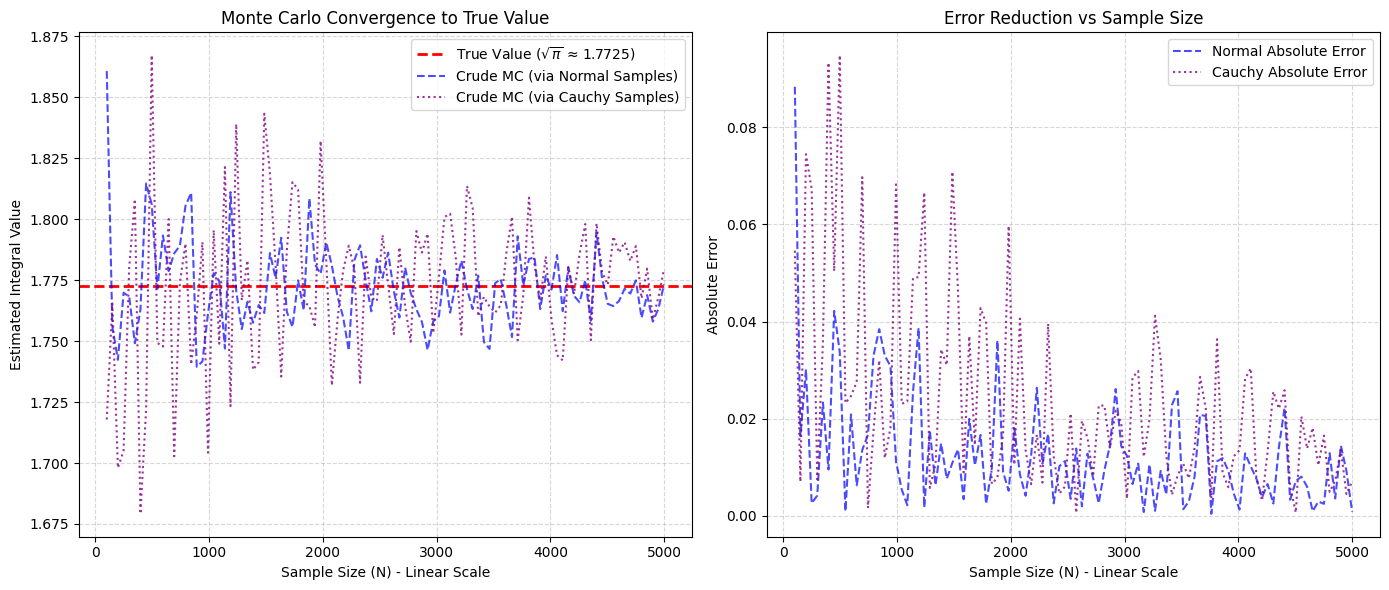

In [ ]:
# =====================================================================
# 5. CONVERGENCE VISUALIZATION PLOTS
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left Plot: Value Convergence Graph
ax1.axhline(y=true_value, color='red', linestyle='--', linewidth=2, label=fr'True Value ($\sqrt{{\pi}}$ ≈ {true_value:.4f})')
ax1.plot(sample_sizes, normal_estimates, color='blue', linestyle='--', alpha=0.7, label='Crude MC (via Normal Samples)')
ax1.plot(sample_sizes, cauchy_estimates, color='purple', linestyle=':', alpha=0.8, label='Crude MC (via Cauchy Samples)')
ax1.set_xlabel('Sample Size (N) - Linear Scale')
ax1.set_ylabel('Estimated Integral Value')
ax1.set_title('Monte Carlo Convergence to True Value')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Right Plot: Error Decaying Rate Graph
ax2.plot(sample_sizes, normal_errors, color='blue', linestyle='--', alpha=0.7, label='Normal Absolute Error')
ax2.plot(sample_sizes, cauchy_errors, color='purple', linestyle=':', alpha=0.8, label='Cauchy Absolute Error')
ax2.set_xlabel('Sample Size (N) - Linear Scale')
ax2.set_ylabel('Absolute Error')
ax2.set_title('Error Reduction vs Sample Size')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


#### **Problem 2:** Evaluate the integral $\theta = \int_{0}^{1} \frac{\sin x}{x} \, dx \approx 0.94608$.

Compare Crude Monte Carlo and Importance Sampling.



### 1. Crude Monte Carlo
We draw samples directly from a standard Uniform distribution $U_i \sim \text{Unif}(0,1)$:

$$\hat{\theta}_{\text{Crude}} = \frac{1}{n} \sum_{i=1}^{n} \frac{\sin U_i}{U_i}.$$

---

### 2. Importance Sampling (Linear Proposal: $2(1-x)$)

We sample from $g(x)=2(1-x)$ on $[0,1]$, with $\int_0^1g(x)\,dx=1$.

**A. Inverse Transform Sampling:**  
The CDF is $U=2x-x^2$, giving

$$
X=1-\sqrt{1-U},\qquad U\sim\text{Unif}(0,1).
$$

**B. Estimator:**

$$
\hat{\theta}_{\text{IS}}
=\frac{1}{n}\sum_{i=1}^{n}
\frac{\frac{\sin X_i}{X_i}}{2(1-X_i)}.
$$

In [ ]:

# Target integrand function h(x) = sin(x)/x
def h(x):
    return np.sinc(x / np.pi)

# Bounded normalized linear proposal PDF on [0, 1]
def linear_pdf(x):
    return 2 * (1.0 - x)

# =====================================================================
# SIMULATION CORE INTEGRATION LOOP (COUPLED RANDOM NUMBERS)
# =====================================================================
true_value, _ = integrate.quad(lambda x: np.sin(x)/x, 0, 1)

# Sample size range
sample_sizes = np.linspace(100, 5000, num=100, dtype=int)

crude_estimates = []
is_estimates = []

for n in sample_sizes:
    # Generate a SINGLE set of uniform random variables for this step
    u_samples = rng.uniform(0.0, 1.0, n)

    # 1. Crude Monte Carlo (Uses the uniform samples directly)
    est_crude = np.mean(h(u_samples))
    crude_estimates.append(est_crude)

    # 2. Importance Sampling (Transforms the EXACT SAME uniform samples)
    x_linear = 1.0 - np.sqrt(1.0 - u_samples)
    est_is = np.mean(h(x_linear) / linear_pdf(x_linear))
    is_estimates.append(est_is)

# Convert arrays for error diagnostics
crude_estimates = np.array(crude_estimates)
is_estimates = np.array(is_estimates)

crude_errors = np.abs(crude_estimates - true_value)
is_errors = np.abs(is_estimates - true_value)


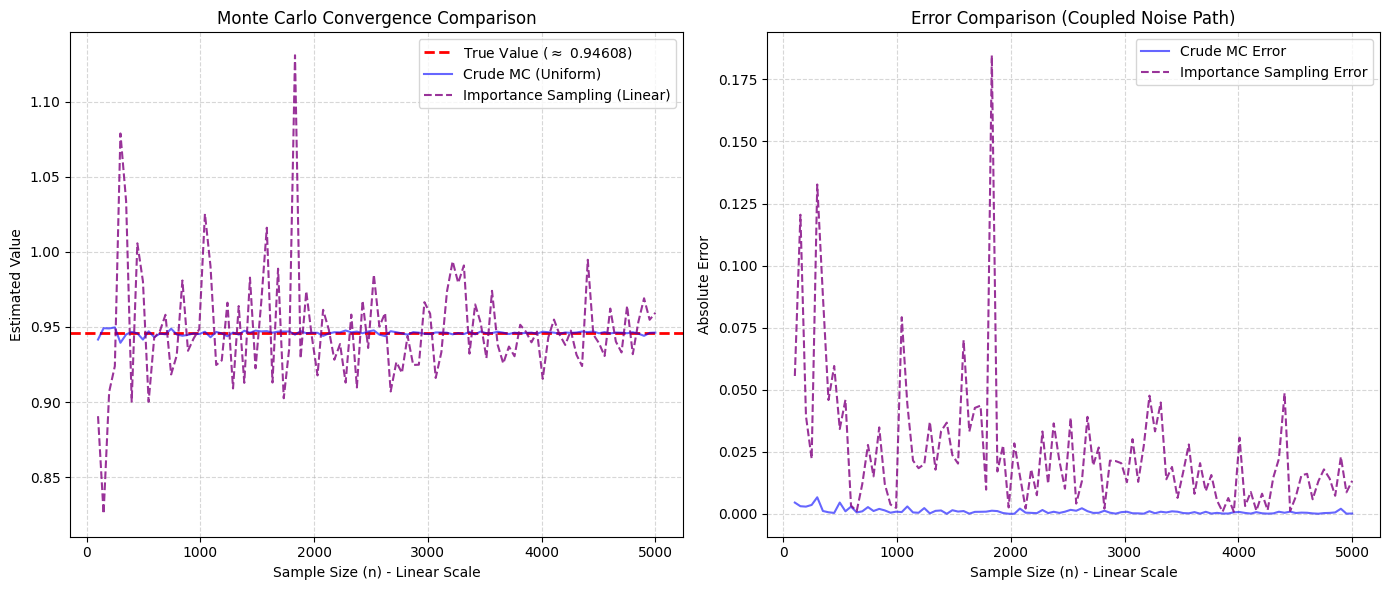

In [ ]:
# =====================================================================
# VISUALIZATION PLOTS
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left Plot: Convergence Value Path
ax1.axhline(y=true_value, color='red', linestyle='--', linewidth=2, label=fr'True Value ($\approx$ {true_value:.5f})')
ax1.plot(sample_sizes, crude_estimates, color='blue', linestyle='-', alpha=0.6, label='Crude MC (Uniform)')
ax1.plot(sample_sizes, is_estimates, color='purple', linestyle='--', alpha=0.8, label='Importance Sampling (Linear)')
ax1.set_xlabel('Sample Size (n)')
ax1.set_ylabel('Estimated Value')
ax1.set_title('Monte Carlo Convergence Comparison')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Right Plot: Absolute Error
ax2.plot(sample_sizes, crude_errors, color='blue', linestyle='-', alpha=0.6, label='Crude MC Error')
ax2.plot(sample_sizes, is_errors, color='purple', linestyle='--', alpha=0.8, label='Importance Sampling Error')
ax2.set_xlabel('Sample Size (n)')
ax2.set_ylabel('Absolute Error')
ax2.set_title('Error Comparison (Coupled Noise Path)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 3. Importance Sampling (Symmetric Triangular Proposal)

We use the symmetric triangular density on $[0,1]$:

$$
g(x)=
\begin{cases}
4x, & 0\leq x\leq0.5,\\
4(1-x), & 0.5<x\leq1.
\end{cases}
$$

**A. Inverse Transform Sampling:**

$$
X=
\begin{cases}
\sqrt{\frac{U}{2}}, & 0\leq U\leq0.5,\\
1-\sqrt{\frac{1-U}{2}}, & 0.5<U\leq1,
\end{cases}
\qquad U\sim\text{Unif}(0,1).
$$

**B. Estimator:**

$$
\hat{\theta}_{\text{IS}}
=\frac{1}{n}\sum_{i=1}^{n}
\frac{\frac{\sin X_i}{X_i}}{g(X_i)}.
$$


In [ ]:
# Symmetric triangular proposal PDF on [0, 1] peaking at 0.5
def triangular_pdf(x):
    return stats.triang.pdf(x, c=0.5, loc=0.0, scale=1.0)

# =====================================================================
# SIMULATION CORE INTEGRATION LOOP (COUPLED RANDOM NUMBERS)
# =====================================================================
true_value, _ = integrate.quad(lambda x: np.sin(x)/x, 0, 1)

# Sample size range
sample_sizes = np.linspace(100, 5000, num=100, dtype=int)

crude_estimates = []
is_estimates = []

for n in sample_sizes:
    # Generate a SINGLE set of uniform random variables for this step
    u_samples = rng.uniform(0.0, 1.0, n)

    # 1. Crude Monte Carlo (Uses the uniform samples directly)
    est_crude = np.mean(h(u_samples))
    crude_estimates.append(est_crude)

    # 2. Importance Sampling (Transforms the EXACT SAME uniform samples via Triangular PPF)
    x_triangular = stats.triang.ppf(u_samples, c=0.5, loc=0.0, scale=1.0)
    est_is = np.mean(h(x_triangular) / triangular_pdf(x_triangular))
    is_estimates.append(est_is)

# Convert arrays for error diagnostics
crude_estimates = np.array(crude_estimates)
is_estimates = np.array(is_estimates)

crude_errors = np.abs(crude_estimates - true_value)
is_errors = np.abs(is_estimates - true_value)



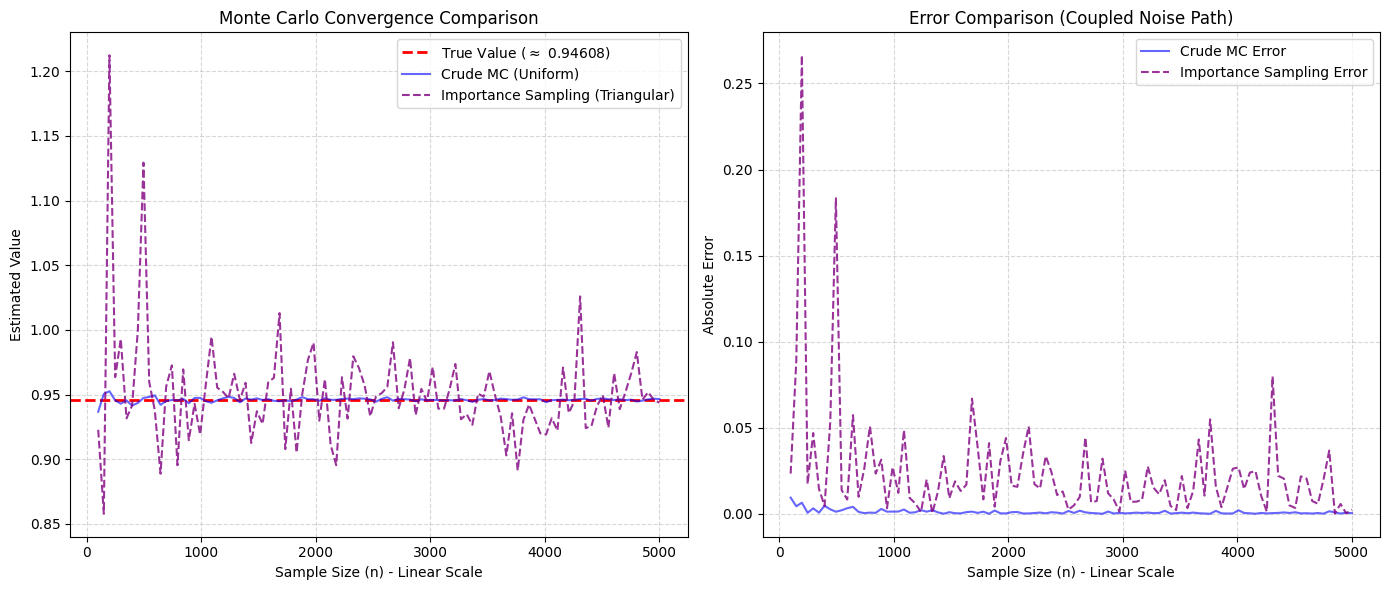

In [ ]:
# =====================================================================
# VISUALIZATION PLOTS
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left Plot: Convergence Value Path
ax1.axhline(y=true_value, color='red', linestyle='--', linewidth=2, label=fr'True Value ($\approx$ {true_value:.5f})')
ax1.plot(sample_sizes, crude_estimates, color='blue', linestyle='-', alpha=0.6, label='Crude MC (Uniform)')
ax1.plot(sample_sizes, is_estimates, color='purple', linestyle='--', alpha=0.8, label='Importance Sampling (Triangular)')
ax1.set_xlabel('Sample Size (n) ')
ax1.set_ylabel('Estimated Value')
ax1.set_title('Monte Carlo Convergence Comparison')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Right Plot: Absolute Error
ax2.plot(sample_sizes, crude_errors, color='blue', linestyle='-', alpha=0.6, label='Crude MC Error')
ax2.plot(sample_sizes, is_errors, color='purple', linestyle='--', alpha=0.8, label='Importance Sampling Error')
ax2.set_xlabel('Sample Size (n) ')
ax2.set_ylabel('Absolute Error')
ax2.set_title('Error Comparison (Coupled Noise Path)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


#### **Problem 3**: Estimating Rare-Event Probabilities via Shifted Importance Sampling

We wish to evaluate the rare-event probability

$$
\theta = P(X > 6),
$$

where $X$ follows a Standard Normal distribution $N(0,1)$. The exact theoretical value calculated via the high-precision survival function is exceptionally tiny:

$$
\theta \approx 9.87 \times 10^{-10}.
$$

---

### 1. The Operational Failure of Crude Monte Carlo

Under standard Crude Monte Carlo, we sample directly from the nominal distribution $X_i \sim N(0,1)$ and evaluate the indicator function $h(x) = \mathbf{1}_{\{x>6\}}$:

$$
\hat{\theta}_{\text{Crude}}
=
\frac{1}{n}
\sum_{i=1}^{n}
\mathbf{1}_{\{X_i>6\}}.
$$

As shown in the lecture, because the true probability is on the order of $10^{-10}$, you would mathematically need to draw roughly **10 million samples** just to observe a single acceptance event ($X_i>6$). For standard classroom simulation sizes ($n=100$ to $5000$), Crude Monte Carlo will return a flat, useless estimate of exactly `0.0`.

---

### 2. Shifted Importance Sampling (Proposal Center Mutation)

To resolve this limitation, we shift the location parameter of our sampling distribution directly onto the rare-event boundary, choosing a mutated proposal distribution $g(x) \sim N(6,1)$.

#### A. Analytical Derivation of the Likelihood Weights

Let $f(x)=\phi(x)$ represent the nominal standard normal density, and let $g(x)=\phi(x-6)$ represent our shifted proposal normal density.

The importance sampling weight is

$$
w(x)
=
\frac{f(x)}{g(x)}
=
\frac{
\frac{1}{\sqrt{2\pi}}e^{-x^2/2}
}{
\frac{1}{\sqrt{2\pi}}e^{-(x-6)^2/2}
}.
$$

#### B. The Unbiased Importance Sampling Estimator

By generating independent samples $X_1,X_2,\dots,X_n \sim N(6,1)$, roughly 50% of all generated observations will naturally fall inside the target region ($X_i>6$). The estimator scales these hits by the likelihood weight to maintain unbiasedness:

$$
\hat{\theta}_{\text{IS}}
=
\frac{1}{n}
\sum_{i=1}^{n}
e^{-6X_i+18}
\mathbf{1}_{\{X_i>6\}}.
$$

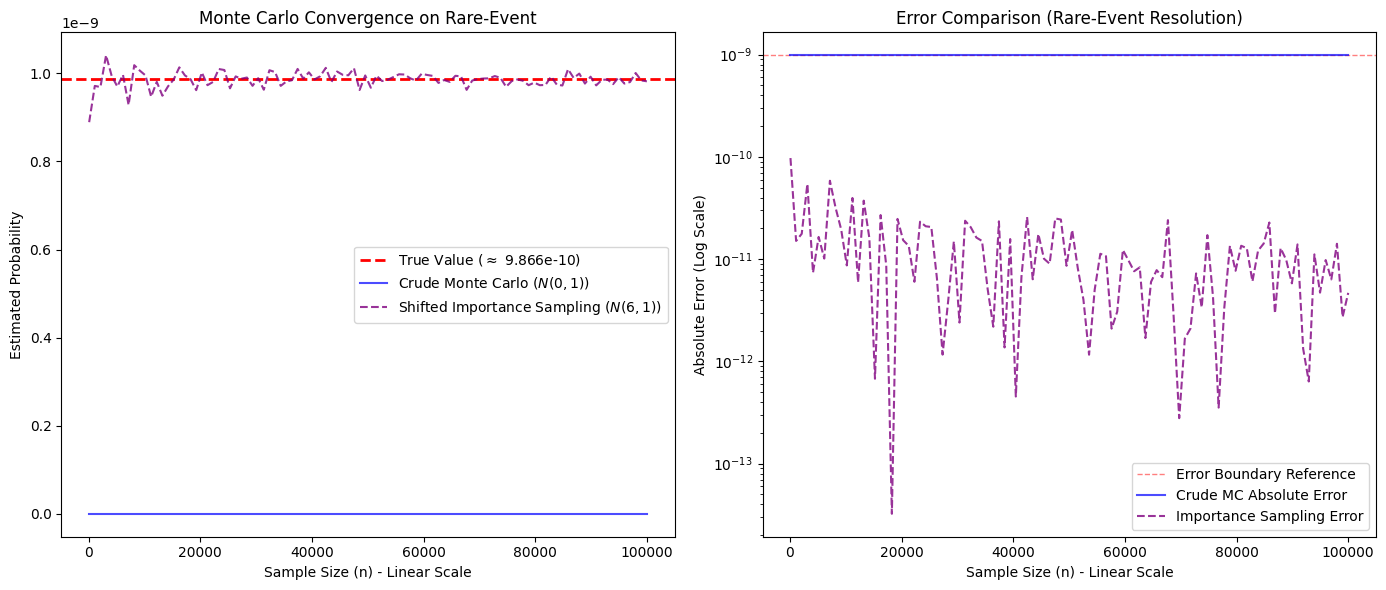

In [ ]:
# Ground Truth calculation using the high-precision Survival Function (1 - CDF)
true_value = stats.norm.sf(6.0)

# Custom Inverse Transform Sampling for Normal Distributions
def sample_normal(k, mean, rng):
    """Generate k samples from N(mean, 1) using Inverse Transform Method."""
    u = rng.random(k)
    standard_normal = np.sqrt(2.0) * erfinv(2.0 * u - 1.0)
    return standard_normal + mean

# =====================================================================
# SIMULATION CORE INTEGRATION LOOP
# =====================================================================
# Testing sample sizes up to 5,000 observations as requested
sample_sizes = np.linspace(100, 100000, num=100, dtype=int)

crude_estimates = []
is_estimates = []

for N in sample_sizes:
    # 1. Crude Monte Carlo (Direct Standard Normal Draws)
    x_crude = sample_normal(N, mean=0.0, rng=rng)
    # Indicator function evaluates to 1 if x > 6, else 0
    est_crude = np.mean(x_crude > 6.0)
    crude_estimates.append(est_crude)

    # 2. Shifted Importance Sampling (Draws from N(6, 1))
    x_shifted = sample_normal(N, mean=6.0, rng=rng)

    # Likelihood ratio weight formula derived on slides: exp(-6x + 18)
    weights = np.exp(-6.0 * x_shifted + 18.0)
    is_terms = weights * (x_shifted > 6.0)

    est_is = np.mean(is_terms)
    is_estimates.append(est_is)

# Convert to arrays for calculations
crude_estimates = np.array(crude_estimates)
is_estimates = np.array(is_estimates)

crude_errors = np.abs(crude_estimates - true_value)
is_errors = np.abs(is_estimates - true_value)

# =====================================================================
# VISUALIZATION PLOTS (SIMPLE CLEAN LINE STYLES, NO DOT MARKERS)
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left Plot: Convergence Value Path
ax1.axhline(y=true_value, color='red', linestyle='--', linewidth=2, label=fr'True Value ($\approx$ {true_value:.3e})')
ax1.plot(sample_sizes, crude_estimates, color='blue', linestyle='-', alpha=0.7, label='Crude Monte Carlo ($N(0,1)$)')
ax1.plot(sample_sizes, is_estimates, color='purple', linestyle='--', alpha=0.8, label='Shifted Importance Sampling ($N(6,1)$)')
ax1.set_xlabel('Sample Size (n) ')
ax1.set_ylabel('Estimated Probability')
ax1.set_title('Monte Carlo Convergence on Rare-Event')
ax1.legend()

# Right Plot: Absolute Error (Logarithmic y-axis is necessary here because true value is ~10^-10)
ax2.axhline(y=true_value, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Error Boundary Reference')
ax2.plot(sample_sizes, crude_errors, color='blue', linestyle='-', alpha=0.7, label='Crude MC Absolute Error')
ax2.plot(sample_sizes, is_errors, color='purple', linestyle='--', alpha=0.8, label='Importance Sampling Error')
ax2.set_yscale('log')
ax2.set_xlabel('Sample Size (n)')
ax2.set_ylabel('Absolute Error (Log Scale)')
ax2.set_title('Error Comparison (Rare-Event Resolution)')
ax2.legend()

plt.tight_layout()
plt.show()
